In [216]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

In [217]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["svg.fonttype"] = "none"

# Experiment 1

## load layouts and quantification files

In [218]:
Experiment1_Layout = pd.read_csv("/Users/alexandergillis/Desktop/KATANA_PULL/blana/Alex/260119_CytoplasmicPOLR2A_60x/260119_CytoplasmicPOLR2A.csv")

In [219]:
quantification_directory_1 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/260119_CytoplasmicPOLR2A/40x/20260128_175303_338/QUANTIFICATION/")
quantification_files_1 = glob.glob(str(quantification_directory_1 / "*.csv"))
len(quantification_files_1)

1539

In [220]:
Nuclei_quant_files = [i for i in quantification_files_1 if "nuclei_" in i]
Cyto_quant_files = [i for i in quantification_files_1 if "cyto_" in i]
Cell_quant_files = [i for i in quantification_files_1 if "cells_" in i]

In [221]:
# use WellC03 to define zeros for 561 and 647 channels, no IF
if_zeros = [x for x in Nuclei_quant_files if "C03" in x]

In [222]:
qdfs = list()


for f in tqdm(if_zeros):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_1['file'].tolist()


wellnames = [f[11:14] for f in files]
quantifcation_pernuc_1['well'] = wellnames

fovs = [f[49:53] for f in files]
quantifcation_pernuc_1['fov'] = fovs

100%|████████████████████████████████████████████| 9/9 [00:00<00:00, 147.76it/s]


In [223]:
IF_561_Zero, IF_640_Zero = quantifcation_pernuc_1['Nuclei_intensity_mean_561_2'].mean(), quantifcation_pernuc_1['Nuclei_intensity_mean_640_0'].mean()

In [224]:
qdfs = list()


for f in tqdm(Cell_quant_files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_1['file'].tolist()


wellnames = [f[10:13] for f in files]
quantifcation_percell_1['well'] = wellnames

fovs = [f[48:52] for f in files]
quantifcation_percell_1['fov'] = fovs

100%|████████████████████████████████████████| 513/513 [00:02<00:00, 189.79it/s]


In [225]:
qdfs = list()


for f in tqdm(Nuclei_quant_files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_1['file'].tolist()


wellnames = [f[11:14] for f in files]
quantifcation_pernuc_1['well'] = wellnames

fovs = [f[49:53] for f in files]
quantifcation_pernuc_1['fov'] = fovs

100%|████████████████████████████████████████| 513/513 [00:02<00:00, 214.85it/s]


In [226]:
qdfs = list()


for f in tqdm(Cyto_quant_files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percyto_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percyto_1['file'].tolist()


wellnames = [f[9:12] for f in files]
quantifcation_percyto_1['well'] = wellnames

fovs = [f[47:51] for f in files]
quantifcation_percyto_1['fov'] = fovs

100%|████████████████████████████████████████| 513/513 [00:01<00:00, 268.30it/s]


In [227]:
# exclude border cells
quantifcation_percell_1 = quantifcation_percell_1.query('Cells_is_border == False')

In [228]:
Intensities = pd.DataFrame({
    "WELL" : quantifcation_percell_1['well'],
    "FOV" : quantifcation_percell_1['fov'],
    "LABEL" : quantifcation_percell_1['label'],
    "CELL_IF_647_Intensity" : quantifcation_percell_1['Cells_intensity_mean_640_0'],
    "CELL_IF_561_Intensity" : quantifcation_percell_1['Cells_intensity_mean_561_2'],
    "CellArea" : quantifcation_percell_1['Cells_area']
})

In [229]:
IntensitiesPerNuclei = pd.DataFrame({
    "WELL" : quantifcation_pernuc_1['well'],
    "FOV" : quantifcation_pernuc_1['fov'],
    "LABEL" : quantifcation_pernuc_1['label'],
    "NUCLEUS_IF_647_Intensity" : quantifcation_pernuc_1['Nuclei_intensity_mean_640_0'],
    "NUCLEUS_IF_561_Intensity" : quantifcation_pernuc_1['Nuclei_intensity_mean_561_2'],
    "Nucleus_DAPI_Intensity" : quantifcation_pernuc_1['Nuclei_intensity_mean_405_5'],
    "NucleusArea" : quantifcation_pernuc_1['Nuclei_area']
})

In [230]:
IntensitiesPerCyto = pd.DataFrame({
    "WELL" : quantifcation_percyto_1['well'],
    "FOV" : quantifcation_percyto_1['fov'],
    "LABEL" : quantifcation_percyto_1['label'],
    "CYTO_IF_647_Intensity" : quantifcation_percyto_1['Cytoplasm_intensity_mean_640_0'],
    "CYTO_IF_561_Intensity" : quantifcation_percyto_1['Cytoplasm_intensity_mean_561_2'],
    "CytoplasmArea" : quantifcation_percyto_1['Cytoplasm_area']
})

## subtract background

In [231]:
Intensities["CELL_IF_647_Intensity_BGS"] = Intensities["CELL_IF_647_Intensity"] - IF_640_Zero
Intensities["CELL_IF_561_Intensity_BGS"] = Intensities["CELL_IF_561_Intensity"] - IF_561_Zero

IntensitiesPerNuclei["NUCLEUS_IF_647_Intensity_BGS"] = IntensitiesPerNuclei["NUCLEUS_IF_647_Intensity"] - IF_640_Zero
IntensitiesPerNuclei["NUCLEUS_IF_561_Intensity_BGS"] = IntensitiesPerNuclei["NUCLEUS_IF_561_Intensity"] - IF_561_Zero

IntensitiesPerCyto["CYTO_IF_647_Intensity_BGS"] = IntensitiesPerCyto["CYTO_IF_647_Intensity"] - IF_640_Zero
IntensitiesPerCyto["CYTO_IF_561_Intensity_BGS"] = IntensitiesPerCyto["CYTO_IF_561_Intensity"] - IF_561_Zero

In [232]:
Intensities = Intensities.merge(IntensitiesPerNuclei, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])
Intensities = Intensities.merge(IntensitiesPerCyto, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])

In [233]:
## exclude cells with missing segmentation
Intensities.dropna(inplace = True)

In [234]:
## filter for cells with some segmented nuclei of minimum size contained within
Intensities = Intensities.query('NucleusArea > 500')

In [235]:
CountsByWell = Intensities.groupby('WELL').count()['NucleusArea'].reset_index().merge(Experiment1_Layout, how = 'left')
CountsByWell.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)

In [236]:
IntensitiesByCell = Intensities.merge(Experiment1_Layout, how = 'left')

In [237]:
IntensitiesByWell = Intensities.drop(['FOV','LABEL'], axis = 1).groupby('WELL').mean().reset_index().merge(Experiment1_Layout, how = 'left')
IntensitiesByWell = IntensitiesByWell.merge(CountsByWell, how = 'left')

## normalise

In [238]:
IntensitiesByWell.CELL.unique(), IntensitiesByWell.PRIMARY_1.unique(), IntensitiesByWell.PRIMARY_2.unique()

(array(['HCT116', 'HCT116 mChPOLR2A clone 2'], dtype=object),
 array(['No primary', 'Total Pol II (F12)'], dtype=object),
 array(['No primary', 'mCherry'], dtype=object))

In [239]:
HCT116_IF_NormValue = IntensitiesByWell.query('DRUG == "No addition" & CELL == "HCT116" & PRIMARY_1 == "Total Pol II (F12)"')['NUCLEUS_IF_647_Intensity_BGS'].mean()

IntensitiesByWell['NUCLEUS_F12_NORM'] = IntensitiesByWell['NUCLEUS_IF_647_Intensity_BGS'] / HCT116_IF_NormValue
IntensitiesByWell['CYTO_F12_NORM'] = IntensitiesByWell['CYTO_IF_647_Intensity_BGS'] / HCT116_IF_NormValue

In [240]:
HCT116_IF_CYTO_NormValue = IntensitiesByWell.query('DRUG == "No addition" & CELL == "HCT116" & PRIMARY_1 == "Total Pol II (F12)"')['CYTO_IF_647_Intensity_BGS'].mean()

IntensitiesByWell['CYTO_F12_NORM2'] = IntensitiesByWell['CYTO_IF_647_Intensity_BGS'] / HCT116_IF_CYTO_NormValue

In [241]:
HCT116_mCh_647_NormValue = IntensitiesByWell.query('DRUG == "No addition" & CELL == "HCT116 mChPOLR2A clone 2" & PRIMARY_1 == "Total Pol II (F12)"')['NUCLEUS_IF_647_Intensity_BGS'].mean()
IntensitiesByWell['NUCLEUS_F12_NORM_MCHPOL'] = IntensitiesByWell['NUCLEUS_IF_647_Intensity_BGS'] / HCT116_mCh_647_NormValue
IntensitiesByWell['CYTO_F12_NORM_MCHPOL'] = IntensitiesByWell['CYTO_IF_647_Intensity_BGS'] / HCT116_mCh_647_NormValue

In [242]:
HCT116_mCh_647_CYTO_NormValue = IntensitiesByWell.query('DRUG == "No addition" & CELL == "HCT116 mChPOLR2A clone 2" & PRIMARY_1 == "Total Pol II (F12)"')['CYTO_IF_647_Intensity_BGS'].mean()

IntensitiesByWell['CYTO_F12_NORM_MCHPOL2'] = IntensitiesByWell['CYTO_IF_647_Intensity_BGS'] / HCT116_mCh_647_CYTO_NormValue

In [243]:
HCT116_mCh_561_NormValue = IntensitiesByWell.query('DRUG == "No addition" & CELL == "HCT116 mChPOLR2A clone 2" & PRIMARY_2 == "mCherry"')['NUCLEUS_IF_561_Intensity_BGS'].mean()

IntensitiesByWell['NUCLEUS_MCH_NORM'] = IntensitiesByWell['NUCLEUS_IF_561_Intensity_BGS'] / HCT116_mCh_561_NormValue
IntensitiesByWell['CYTO_MCH_NORM'] = IntensitiesByWell['CYTO_IF_561_Intensity_BGS'] / HCT116_mCh_561_NormValue

In [244]:
HCT116_mCh_561_CYTO_NormValue = IntensitiesByWell.query('DRUG == "No addition" & CELL == "HCT116 mChPOLR2A clone 2" & PRIMARY_2 == "mCherry"')['CYTO_IF_561_Intensity_BGS'].mean()

IntensitiesByWell['CYTO_MCH_NORM2'] = IntensitiesByWell['CYTO_IF_561_Intensity_BGS'] / HCT116_mCh_561_CYTO_NormValue

# Experiment 2

In [245]:
Experiment2_Layout = pd.read_csv("/Users/alexandergillis/Desktop/KATANA_PULL/blana/Alex/260306_CytoplasmicPOLR2A/260306_CytoplasmicPOLR2A.csv")

In [246]:
quantification_directory_2 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/260306_CytoplasmicPOLR2A/20260310_190059_521/QUANTIFICATION/")
quantification_files_2 = glob.glob(str(quantification_directory_2 / "*.csv"))
len(quantification_files_2)

2160

In [247]:
Nuclei_quant_files = [i for i in quantification_files_2 if "nuclei_" in i]
Cyto_quant_files = [i for i in quantification_files_2 if "cyto_" in i]
Cell_quant_files = [i for i in quantification_files_2 if "cells_" in i]

In [248]:
qdfs = list()


for f in tqdm(Cell_quant_files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_2['file'].tolist()


wellnames = [f[10:13] for f in files]
quantifcation_percell_2['well'] = wellnames

fovs = [f[48:52] for f in files]
quantifcation_percell_2['fov'] = fovs

100%|████████████████████████████████████████| 720/720 [00:03<00:00, 187.70it/s]


In [249]:
Path(Nuclei_quant_files[10]).stem, Path(Nuclei_quant_files[10]).stem[11:14],Path(Nuclei_quant_files[10]).stem[49:53]

('nuclei_WellD06_Channel647,488,561,XXX,XXX,405_Seq0002_0001.ome',
 'D06',
 '0002')

In [250]:
qdfs = list()


for f in tqdm(Nuclei_quant_files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_2['file'].tolist()


wellnames = [f[11:14] for f in files]
quantifcation_pernuc_2['well'] = wellnames

fovs = [f[49:53] for f in files]
quantifcation_pernuc_2['fov'] = fovs

100%|████████████████████████████████████████| 720/720 [00:03<00:00, 195.22it/s]


In [251]:
Path(Cyto_quant_files[10]).stem, Path(Cyto_quant_files[10]).stem[9:12],Path(Cyto_quant_files[10]).stem[47:51]

('cyto_WellE14_Channel647,488,561,XXX,XXX,405_Seq0055_0009.ome', 'E14', '0055')

In [252]:
qdfs = list()


for f in tqdm(Cyto_quant_files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percyto_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percyto_2['file'].tolist()


wellnames = [f[9:12] for f in files]
quantifcation_percyto_2['well'] = wellnames

fovs = [f[47:51] for f in files]
quantifcation_percyto_2['fov'] = fovs

100%|████████████████████████████████████████| 720/720 [00:03<00:00, 182.87it/s]


In [253]:
# exclude border cells
quantifcation_percell_2 = quantifcation_percell_2.query('Cells_is_border == False')

In [254]:
Intensities2 = pd.DataFrame({
    "WELL" : quantifcation_percell_2['well'],
    "FOV" : quantifcation_percell_2['fov'],
    "LABEL" : quantifcation_percell_2['label'],
    "CELL_IF_647_Intensity" : quantifcation_percell_2['Cells_intensity_mean_647_0'],
    "CELL_IF_561_Intensity" : quantifcation_percell_2['Cells_intensity_mean_561_2'],
    "CellArea" : quantifcation_percell_2['Cells_area']
})

In [255]:
IntensitiesPerNuclei2 = pd.DataFrame({
    "WELL" : quantifcation_pernuc_2['well'],
    "FOV" : quantifcation_pernuc_2['fov'],
    "LABEL" : quantifcation_pernuc_2['label'],
    "NUCLEUS_IF_647_Intensity" : quantifcation_pernuc_2['Nuclei_intensity_mean_647_0'],
    "NUCLEUS_IF_561_Intensity" : quantifcation_pernuc_2['Nuclei_intensity_mean_561_2'],
    "Nucleus_DAPI_Intensity" : quantifcation_pernuc_2['Nuclei_intensity_mean_405_5'],
    "NucleusArea" : quantifcation_pernuc_2['Nuclei_area']
})

In [256]:
IntensitiesPerCyto2 = pd.DataFrame({
    "WELL" : quantifcation_percyto_2['well'],
    "FOV" : quantifcation_percyto_2['fov'],
    "LABEL" : quantifcation_percyto_2['label'],
    "CYTO_IF_647_Intensity" : quantifcation_percyto_2['Cytoplasm_intensity_mean_647_0'],
    "CYTO_IF_561_Intensity" : quantifcation_percyto_2['Cytoplasm_intensity_mean_561_2'],
    "CytoplasmArea" : quantifcation_percyto_2['Cytoplasm_area']
})

In [257]:
Intensities2 = Intensities2.merge(IntensitiesPerNuclei2, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])
Intensities2 = Intensities2.merge(IntensitiesPerCyto2, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])

In [258]:
## exclude cells with missing segmentation
Intensities2.dropna(inplace = True)

In [259]:
## filter for cells with some nucleus segmented over a certain area
Intensities2 = Intensities2.query('NucleusArea > 500')

In [260]:
CountsByWell2 = Intensities2.groupby('WELL').count()['NucleusArea'].reset_index().merge(Experiment2_Layout, how = 'left')
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)

In [261]:
IntensitiesByCell2 = Intensities2.merge(Experiment2_Layout, how = 'left')

In [262]:
IntensitiesByWell2 = Intensities2.drop(['FOV','LABEL'], axis = 1).groupby('WELL').mean().reset_index().merge(Experiment2_Layout, how = 'left')
IntensitiesByWell2 = IntensitiesByWell2.merge(CountsByWell, how = 'left')

## background subtract and normalise

In [263]:
IntensitiesByWell2.CELL.unique(), IntensitiesByWell2.PRIMARY_1.unique(), IntensitiesByWell2.PRIMARY_2.unique()

(array(['HCT116', 'HCT116 mChPOLR2A clone 2'], dtype=object),
 array(['Total Pol II (F12)', 'No primary'], dtype=object),
 array(['Total Pol II (D8L4Y)', 'mCherry', 'No primary'], dtype=object))

In [264]:
IF_647_Zero, IF_561_Zero = IntensitiesByWell2.query('PRIMARY_1 == "No primary"')['CELL_IF_647_Intensity'].mean(), IntensitiesByWell2.query('PRIMARY_2 == "No primary"')['CELL_IF_561_Intensity'].mean()

In [265]:
IntensitiesByWell2['CELL_IF_647_Intensity_BGS'] = IntensitiesByWell2['CELL_IF_647_Intensity'] - IF_647_Zero
IntensitiesByWell2['CYTO_IF_647_Intensity_BGS'] = IntensitiesByWell2['CYTO_IF_647_Intensity'] - IF_647_Zero
IntensitiesByWell2['NUCLEUS_IF_647_Intensity_BGS'] = IntensitiesByWell2['NUCLEUS_IF_647_Intensity'] - IF_647_Zero

IntensitiesByWell2['CELL_IF_561_Intensity_BGS'] = IntensitiesByWell2['CELL_IF_561_Intensity'] - IF_561_Zero 
IntensitiesByWell2['CYTO_IF_561_Intensity_BGS'] = IntensitiesByWell2['CYTO_IF_561_Intensity'] - IF_561_Zero 
IntensitiesByWell2['NUCLEUS_IF_561_Intensity_BGS'] = IntensitiesByWell2['NUCLEUS_IF_561_Intensity'] - IF_561_Zero 

In [266]:
HCT116_F12_NV = IntensitiesByWell2.query('DRUG == "Vehicle" & CELL == "HCT116" & PRIMARY_1 == "Total Pol II (F12)"')['NUCLEUS_IF_647_Intensity_BGS'].mean()

IntensitiesByWell2['NUCLEUS_F12_NORM'] = IntensitiesByWell2['NUCLEUS_IF_647_Intensity_BGS'] / HCT116_F12_NV
IntensitiesByWell2['CYTO_F12_NORM'] = IntensitiesByWell2['CYTO_IF_647_Intensity_BGS'] / HCT116_F12_NV

In [267]:
HCT116_IF_CYTO_NormValue = IntensitiesByWell2.query('DRUG == "No addition" & CELL == "HCT116" & PRIMARY_1 == "Total Pol II (F12)"')['CYTO_IF_647_Intensity_BGS'].mean()

IntensitiesByWell2['CYTO_F12_NORM2'] = IntensitiesByWell2['CYTO_IF_647_Intensity_BGS'] / HCT116_IF_CYTO_NormValue

In [268]:
HCT116_D8L4Y_NV = IntensitiesByWell2.query('DRUG == "Vehicle" & CELL == "HCT116" & PRIMARY_2 == "Total Pol II (D8L4Y)"')['NUCLEUS_IF_561_Intensity_BGS'].mean()

IntensitiesByWell2['NUCLEUS_D8L4Y_NORM'] = IntensitiesByWell2['NUCLEUS_IF_561_Intensity_BGS'] / HCT116_D8L4Y_NV
IntensitiesByWell2['CYTO_D8L4Y_NORM'] = IntensitiesByWell2['CYTO_IF_561_Intensity_BGS'] / HCT116_D8L4Y_NV

In [269]:
IntensitiesByWell2.query('DRUG == "Vehicle" & CELL == "HCT116 mChPOLR2A clone 2" & PRIMARY_1 == "Total Pol II (F12)"')

,WELL,CELL_IF_647_Intensity,CELL_IF_561_Intensity,CellArea,NUCLEUS_IF_647_Intensity,NUCLEUS_IF_561_Intensity,Nucleus_DAPI_Intensity,NucleusArea,CYTO_IF_647_Intensity,CYTO_IF_561_Intensity,...,CYTO_IF_647_Intensity_BGS,NUCLEUS_IF_647_Intensity_BGS,CELL_IF_561_Intensity_BGS,CYTO_IF_561_Intensity_BGS,NUCLEUS_IF_561_Intensity_BGS,NUCLEUS_F12_NORM,CYTO_F12_NORM,CYTO_F12_NORM2,NUCLEUS_D8L4Y_NORM,CYTO_D8L4Y_NORM
25,E15,330.723585,721.034163,9639.839498,399.415744,887.934199,729.420074,5726.189499,202.016559,401.762236,...,54.492343,251.891528,589.216784,269.944857,756.116820,0.951362,0.205811,NaN,1.969478,0.703133
42,F16,312.867135,705.734986,11195.069926,395.929173,919.279179,645.939503,5997.664200,199.704209,407.334767,...,52.179993,248.404957,573.917607,275.517388,787.461800,0.938194,0.197077,NaN,2.051123,0.717647
59,G17,291.349216,636.783521,10338.193240,355.435792,801.968183,646.521574,5952.779584,191.050901,371.415759,...,43.526685,207.911576,504.966142,239.598380,670.150804,0.785255,0.164395,NaN,1.745560,0.624088


In [270]:
MCHPOL_F12_NV = IntensitiesByWell2.query('DRUG == "Vehicle" & CELL == "HCT116 mChPOLR2A clone 2" & PRIMARY_1 == "Total Pol II (F12)"')['NUCLEUS_IF_647_Intensity_BGS'].mean()
IntensitiesByWell2['NUCLEUS_F12_NORM_MCHPOL'] = IntensitiesByWell2['NUCLEUS_IF_647_Intensity_BGS'] / MCHPOL_F12_NV
IntensitiesByWell2['CYTO_F12_NORM_MCHPOL'] = IntensitiesByWell2['CYTO_IF_647_Intensity_BGS'] / MCHPOL_F12_NV

In [271]:
HCT116_mCh_647_CYTO_NormValue = IntensitiesByWell2.query('DRUG == "No addition" & CELL == "HCT116 mChPOLR2A clone 2" & PRIMARY_1 == "Total Pol II (F12)"')['CYTO_IF_647_Intensity_BGS'].mean()

IntensitiesByWell['CYTO_F12_NORM_MCHPOL2'] = IntensitiesByWell2['CYTO_IF_647_Intensity_BGS'] / HCT116_mCh_647_CYTO_NormValue

In [272]:
MCHPOL_MCH_NV = IntensitiesByWell2.query('DRUG == "Vehicle" & CELL == "HCT116 mChPOLR2A clone 2" & PRIMARY_2 == "mCherry"')['NUCLEUS_IF_561_Intensity_BGS'].mean()

IntensitiesByWell2['NUCLEUS_MCH_NORM'] = IntensitiesByWell2['NUCLEUS_IF_561_Intensity_BGS'] / MCHPOL_MCH_NV
IntensitiesByWell2['CYTO_MCH_NORM'] = IntensitiesByWell2['CYTO_IF_561_Intensity_BGS'] / MCHPOL_MCH_NV

In [273]:
HCT116_mCh_561_CYTO_NormValue = IntensitiesByWell2.query('DRUG == "Vehicle" & CELL == "HCT116 mChPOLR2A clone 2" & PRIMARY_2 == "mCherry"')['CYTO_IF_561_Intensity_BGS'].mean()

IntensitiesByWell2['CYTO_MCH_NORM2'] = IntensitiesByWell2['CYTO_IF_561_Intensity_BGS'] / HCT116_mCh_561_CYTO_NormValue

# concat dataframes and plot replicate wells between experiments

In [274]:
IntensitiesByWell['EXPERIMENT'] = "260119_CytoplasmicPOLR2A"
IntensitiesByWell2['EXPERIMENT'] = "260306_CytoplasmicPOLR2A"

In [275]:
Ints_By_Well = pd.concat([IntensitiesByWell, IntensitiesByWell2])

In [276]:
Ints_By_Well

,WELL,CELL_IF_647_Intensity,CELL_IF_561_Intensity,CellArea,CELL_IF_647_Intensity_BGS,CELL_IF_561_Intensity_BGS,NUCLEUS_IF_647_Intensity,NUCLEUS_IF_561_Intensity,Nucleus_DAPI_Intensity,NucleusArea,...,CYTO_F12_NORM2,NUCLEUS_F12_NORM_MCHPOL,CYTO_F12_NORM_MCHPOL,CYTO_F12_NORM_MCHPOL2,NUCLEUS_MCH_NORM,CYTO_MCH_NORM,CYTO_MCH_NORM2,EXPERIMENT,NUCLEUS_D8L4Y_NORM,CYTO_D8L4Y_NORM
0,C03,160.067518,126.589921,8692.357887,-0.962363,-0.617225,159.987294,126.438883,535.100658,6177.791342,...,-0.021528,-0.003140,-0.003104,NaN,-0.000680,-0.000150,-0.000488,260119_CytoplasmicPOLR2A,NaN,NaN
1,D03,160.697928,126.979662,8359.864152,-0.331952,-0.227484,160.644709,126.848258,575.867548,5736.588156,...,-0.007340,-0.001160,-0.001058,NaN,-0.000318,0.000172,0.000562,260119_CytoplasmicPOLR2A,NaN,NaN
2,D04,463.204034,155.437479,12103.359356,302.174154,28.230333,716.410494,168.882299,578.943715,5277.373074,...,1.462502,1.672682,0.210853,NaN,0.036872,0.012787,0.041653,260119_CytoplasmicPOLR2A,NaN,NaN
3,D05,415.492593,153.094616,12473.549861,254.462713,25.887469,628.657177,165.127797,597.938314,5529.000255,...,1.230303,1.408389,0.177376,NaN,0.033550,0.012826,0.041778,260119_CytoplasmicPOLR2A,NaN,NaN
4,D06,411.305894,150.322115,12778.289283,250.276014,23.114968,617.634968,160.849016,560.504503,5677.732603,...,1.167677,1.375192,0.168347,NaN,0.029764,0.010254,0.033402,260119_CytoplasmicPOLR2A,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,H17,149.363156,694.303926,8954.339568,1.838940,562.486547,150.236221,857.094043,642.018266,5400.692024,...,NaN,0.011488,0.002748,NaN,0.982880,0.375945,1.060096,260306_CytoplasmicPOLR2A,1.889147,0.722586
76,H18,265.022710,571.573999,12146.037162,117.498495,439.756620,330.759951,748.745031,599.939668,6285.473800,...,NaN,0.776195,0.150341,NaN,0.836048,0.289369,0.815968,260306_CytoplasmicPOLR2A,1.606928,0.556182
77,H19,272.977919,585.431940,12540.134222,125.453703,453.614561,343.190111,767.296637,623.201787,6536.195365,...,NaN,0.828849,0.157544,NaN,0.861188,0.293483,0.827569,260306_CytoplasmicPOLR2A,1.655250,0.564090
78,H20,268.931608,568.472985,11494.174624,121.407392,436.655607,324.215896,719.105332,599.918972,6653.345032,...,NaN,0.748474,0.128079,NaN,0.795880,0.252857,0.713011,260306_CytoplasmicPOLR2A,1.529725,0.486005


In [277]:
Ints_By_Well.DRUG.unique(), Ints_By_Well.PRIMARY_1.unique(), Ints_By_Well.PRIMARY_2.unique()

(array(['No addition', 'Media only', 'Mg132 plus leptomycin B', 'Vehicle',
        'Mg132', 'CB6644', 'Leptomycin B', 'Mg132 plus CB6644'],
       dtype=object),
 array(['No primary', 'Total Pol II (F12)'], dtype=object),
 array(['No primary', 'mCherry', 'Total Pol II (D8L4Y)'], dtype=object))

In [278]:
drug_order_plot = ['Vehicle','Mg132','Leptomycin B','Mg132 plus leptomycin B']

In [279]:
pal = sns.color_palette([sns.color_palette('tab20')[15], sns.color_palette('tab20')[1],  sns.color_palette('tab20')[3], sns.color_palette('tab20')[9]])

In [280]:
Ints_By_Well.columns

Index(['WELL', 'CELL_IF_647_Intensity', 'CELL_IF_561_Intensity', 'CellArea',
       'CELL_IF_647_Intensity_BGS', 'CELL_IF_561_Intensity_BGS',
       'NUCLEUS_IF_647_Intensity', 'NUCLEUS_IF_561_Intensity',
       'Nucleus_DAPI_Intensity', 'NucleusArea', 'NUCLEUS_IF_647_Intensity_BGS',
       'NUCLEUS_IF_561_Intensity_BGS', 'CYTO_IF_647_Intensity',
       'CYTO_IF_561_Intensity', 'CytoplasmArea', 'CYTO_IF_647_Intensity_BGS',
       'CYTO_IF_561_Intensity_BGS', 'CELL', 'CELL_STAIN', 'DRUG',
       'DRUG_TIME_MINUTES', 'PRIMARY_1', 'SECONDARY_1', 'PRIMARY_2',
       'SECONDARY_2', 'TotalNumberCells', 'NUCLEUS_F12_NORM', 'CYTO_F12_NORM',
       'CYTO_F12_NORM2', 'NUCLEUS_F12_NORM_MCHPOL', 'CYTO_F12_NORM_MCHPOL',
       'CYTO_F12_NORM_MCHPOL2', 'NUCLEUS_MCH_NORM', 'CYTO_MCH_NORM',
       'CYTO_MCH_NORM2', 'EXPERIMENT', 'NUCLEUS_D8L4Y_NORM',
       'CYTO_D8L4Y_NORM'],
      dtype='object')

## plot with cytoplasmic intenisty normalised to nuclear intensity

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/1564560557.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/1564560557.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()


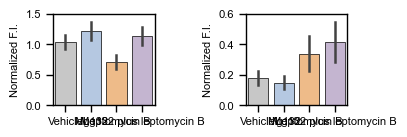

In [281]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (4,1.5))

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'NUCLEUS_F12_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'CYTO_F12_NORM',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,0.6)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

#plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

In [282]:
Ints_By_Well.EXPERIMENT.unique()

array(['260119_CytoplasmicPOLR2A', '260306_CytoplasmicPOLR2A'],
      dtype=object)

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/3847175443.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/3847175443.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()


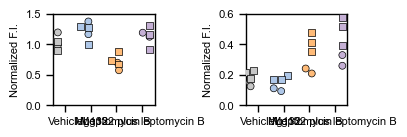

In [283]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (4,1.5))

g = sns.swarmplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot & EXPERIMENT == "260119_CytoplasmicPOLR2A"'),
              x = 'DRUG', order = drug_order_plot,
              y = 'NUCLEUS_F12_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = 1, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                )

g = sns.swarmplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot & EXPERIMENT == "260306_CytoplasmicPOLR2A"'),
              x = 'DRUG', order = drug_order_plot,
              y = 'NUCLEUS_F12_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = 1, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                  marker = 's'
                )
g.legend().remove()

g = sns.swarmplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot & EXPERIMENT == "260119_CytoplasmicPOLR2A"'),
              x = 'DRUG', order = drug_order_plot,
              y = 'CYTO_F12_NORM',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = 1, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                )

g = sns.swarmplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot & EXPERIMENT == "260306_CytoplasmicPOLR2A"'),
              x = 'DRUG', order = drug_order_plot,
              y = 'CYTO_F12_NORM',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = 1, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                  marker = 's'
                )

g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,0.6)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

#plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/879214461.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/879214461.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()


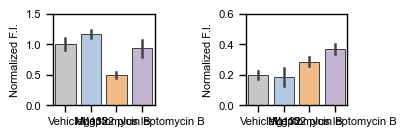

In [284]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (4,1.5))

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'NUCLEUS_F12_NORM_MCHPOL',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'CYTO_F12_NORM_MCHPOL',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,0.6)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

#plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/3190570873.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/3190570873.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an und

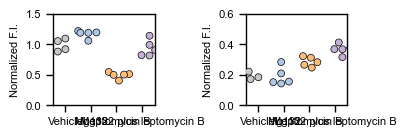

In [285]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (4,1.5))

g = sns.swarmplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'NUCLEUS_F12_NORM_MCHPOL',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = True, palette = pal,
                edgecolor = 'black', linewidth = 0.5
                )
g.legend().remove()

g = sns.swarmplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'CYTO_F12_NORM_MCHPOL',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = True, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                )
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,0.6)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

#plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/1586093927.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/1586093927.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()


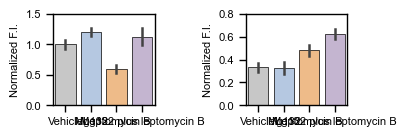

In [286]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (4,1.5))

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'NUCLEUS_MCH_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'CYTO_MCH_NORM',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,0.8)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

#plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

In [287]:
Ints_By_Well.DRUG.unique()

array(['No addition', 'Media only', 'Mg132 plus leptomycin B', 'Vehicle',
       'Mg132', 'CB6644', 'Leptomycin B', 'Mg132 plus CB6644'],
      dtype=object)

In [288]:
sns.color_palette('tab20')

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (1.0, 0.7333333333333333, 0.47058823529411764),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (1.0, 0.596078431372549, 0.5882352941176471),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.7686274509803922, 0.611764705882353, 0.5803921568627451),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.9686274509803922, 0.7137254901960784, 0.8235294117647058),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7803921568627451, 0.7803921568627451, 0.7803921568627451),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.8588235294117647, 0.8588235294117647, 0.5529411764705883),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529),
 (0.6196078431372549, 0.8549019607843137, 0.8980392156862745)]

In [289]:
pal2 = sns.color_palette([sns.color_palette('tab20')[15], sns.color_palette('tab20')[1],  sns.color_palette('tab20')[3], sns.color_palette('tab20')[9], sns.color_palette('tab20')[11], sns.color_palette('tab20')[7]])

In [290]:
drug_order_plot_2 = ['Vehicle','Mg132','Leptomycin B','Mg132 plus leptomycin B', 'CB6644', 'Mg132 plus CB6644']

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/3289754616.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/3289754616.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()


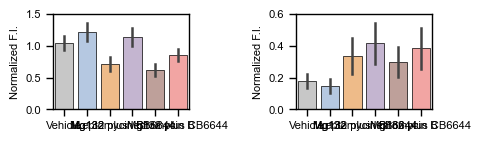

In [291]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (5,1.5))

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot_2'),
              x = 'DRUG', order = drug_order_plot_2,
              y = 'NUCLEUS_F12_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot_2, dodge = False, palette = pal2,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot_2'),
              x = 'DRUG', order = drug_order_plot_2,
              y = 'CYTO_F12_NORM',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot_2, dodge = False, palette = pal2,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,0.6)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.7)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/557900953.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/557900953.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()


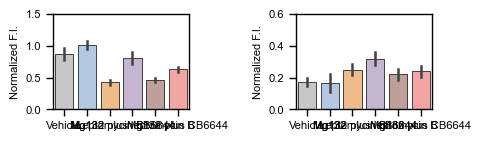

In [292]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (5,1.5))

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot_2'),
              x = 'DRUG', order = drug_order_plot_2,
              y = 'NUCLEUS_F12_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot_2, dodge = False, palette = pal2,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot_2'),
              x = 'DRUG', order = drug_order_plot_2,
              y = 'CYTO_F12_NORM',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot_2, dodge = False, palette = pal2,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,0.6)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.7)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/38715795.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/38715795.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()


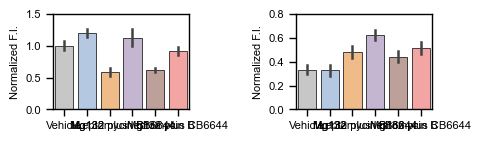

In [293]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (5,1.5))

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot_2'),
              x = 'DRUG', order = drug_order_plot_2,
              y = 'NUCLEUS_MCH_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot_2, dodge = False, palette = pal2,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot_2'),
              x = 'DRUG', order = drug_order_plot_2,
              y = 'CYTO_MCH_NORM',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot_2, dodge = False, palette = pal2,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,0.8)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.7)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

## plot with cytoplasmic intenisty normalised to vehicle

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/3208515755.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/3208515755.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()


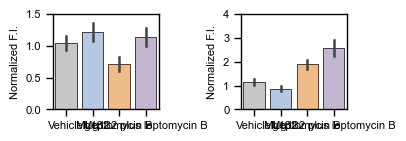

In [294]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (4,1.5))

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'NUCLEUS_F12_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'CYTO_F12_NORM2',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,4)
a[1].set_yticks([0,1,2,3,4])

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/4086913048.py:5: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/4086913048.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/4086913048.py:14: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/4086913048.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whos

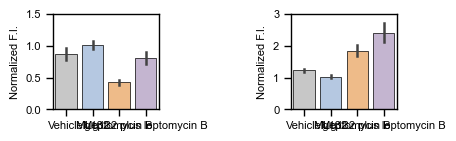

In [305]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (5,1.5))

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'NUCLEUS_F12_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal2,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'CYTO_F12_NORM2',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal2,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,3)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

plt.savefig('mCherryPOLR2A_F12_MG132_LMB_cyto_nuclear.svg')

In [296]:
Ints_By_Well.CYTO_MCH_NORM2

0    -0.000488
1     0.000562
2     0.041653
3     0.041778
4     0.033402
        ...   
75    1.060096
76    0.815968
77    0.827569
78    0.713011
79    0.650359
Name: CYTO_MCH_NORM2, Length: 137, dtype: float64

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/4262824799.py:5: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/4262824799.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/4262824799.py:14: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_14795/4262824799.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whos

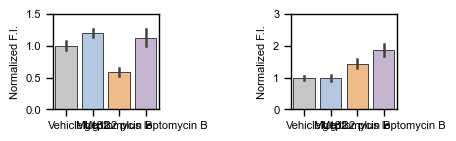

In [304]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (5,1.5))

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'NUCLEUS_MCH_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal2,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'CYTO_MCH_NORM2',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal2,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,3)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

plt.savefig('mCherryPOLR2A_mCherryIF_MG132_LMB_cyto_nuclear.svg')